<a href="https://colab.research.google.com/github/ivanovyeppez/talento-tech/blob/main/Experiencia/Redes_Neuronales_en_NLP_Iy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras

# Montar Google Drive
drive.mount('/content/drive')

# Ruta al archivo en tu Google Drive
ruta = '/content/drive/MyDrive/Datasets/IMDB Dataset.csv'

# Cargar el dataset en un DataFrame
df = pd.read_csv(ruta)

# Mostrar las primeras filas
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [ ]:
#Checking Dataset Description
print(df.describe())

#sentiment count
print("Total :\\n",df['sentiment'].value_counts())

                                                   review sentiment
count                                               50000     50000
unique                                              49582         2
top     Loved today's show!!! It was a variety and not...  positive
freq                                                    5     25000
Total :\n sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [ ]:
review = []
sentences = list(df['review'])
for sen in sentences:
    review.append(sen)

In [ ]:
labels = df['sentiment']
labels = np.array(list(map(lambda x: 1 if x=="positive" else 0, labels)))

from sklearn.model_selection import train_test_split
train_sentences, test_sentences, train_labels, test_labels = train_test_split(review, labels, test_size=0.20)

In [ ]:
from sklearn.model_selection import train_test_split
train_sentences, test_sentences, train_labels, test_labels = train_test_split(review, labels, test_size=0.20)

In [ ]:
# Parameters
vocab_size = 1000
max_length = 120
embedding_dim = 16
trunc_type='post'
oov_tok = "<OOV>"

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


# Initialize the Tokenizer class
tokenizer = Tokenizer(num_words = vocab_size, oov_token=oov_tok)

# Generate the word index dictionary for the training sentences
tokenizer.fit_on_texts(train_sentences)
word_index = tokenizer.word_index

# Generate and pad the training sequences
sequences = tokenizer.texts_to_sequences(train_sentences)
padded = pad_sequences(sequences,maxlen=max_length, truncating=trunc_type)

# Generate and pad the test sequences
test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, maxlen=max_length, truncating=trunc_type)

In [ ]:
# Build the model
model = keras.Sequential([
    keras.layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# Setup the training parameters
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

# Print the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/21
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9983 - loss: 0.0057 - val_accuracy: 0.7588 - val_loss: 2.5199
Epoch 2/21
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9975 - loss: 0.0078 - val_accuracy: 0.7532 - val_loss: 2.5362
Epoch 3/21
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9980 - loss: 0.0073 - val_accuracy: 0.7585 - val_loss: 2.6755
Epoch 4/21
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9985 - loss: 0.0052 - val_accuracy: 0.7603 - val_loss: 2.7469
Epoch 5/21
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9972 - loss: 0.0097 - val_accuracy: 0.7558 - val_loss: 2.6124
Epoch 6/21
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9985 - loss: 0.0054 - val_accuracy: 0.7546 - val_loss: 2.5810
Epoch 7/21
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9976 - loss: 0.0075 - val_accuracy: 0.7642 - val_loss: 2.7769
Epoch 8/21
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9982 - loss: 0.0059 -

<Axes: >

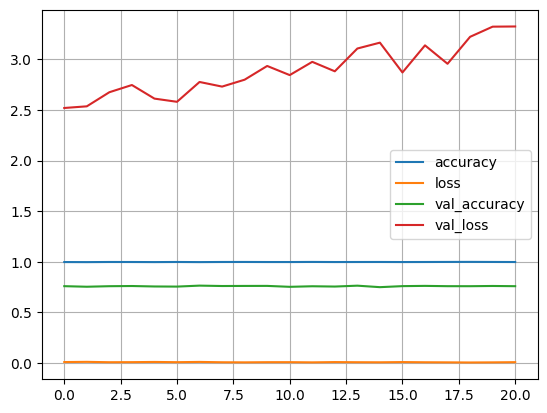

In [ ]:
# Define el número de épocas de entrenamiento
num_epochs = 21

# Train the model
history = model.fit(padded,
                    train_labels,
                    epochs=num_epochs,
                    validation_data=(test_padded, test_labels))

# Graficar el historial de entrenamiento:
pd.DataFrame(history.history).plot(grid=True)

In [ ]:
# Build the model
model = keras.Sequential([
    keras.layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
    keras.layers.LSTM(64, return_sequences=True),
    keras.layers.LSTM(32),
    keras.layers.Dense(6, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
# Setup the training parameters
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

# Print the model summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 167s 104ms/step - accuracy: 0.6112 - loss: 0.6446 - val_accuracy: 0.7476 - val_loss: 0.5209
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 140s 112ms/step - accuracy: 0.7928 - loss: 0.4505 - val_accuracy: 0.8008 - val_loss: 0.4395
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 140s 112ms/step - accuracy: 0.8175 - loss: 0.4139 - val_accuracy: 0.8006 - val_loss: 0.4341
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 132s 104ms/step - accuracy: 0.8143 - loss: 0.4100 - val_accuracy: 0.8067 - val_loss: 0.4217
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 141s 103ms/step - accuracy: 0.8173 - loss: 0.3960 - val_accuracy: 0.8129 - val_loss: 0.4126
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 142s 103ms/step - accuracy: 0.8201 - loss: 0.3944 - val_accuracy: 0.8135 - val_loss: 0.4099
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 141s 103ms/step - accuracy: 0.8256 - loss: 0.3866 - val_accuracy: 0.8059 - val_loss: 0.4734
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 153s 112ms/step - ac

<Axes: >

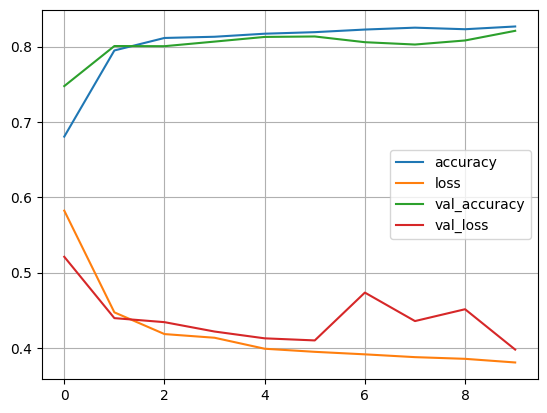

In [ ]:
num_epochs = 10

# Train the model
history = model.fit(padded,
                    train_labels,
                    epochs=num_epochs,
                    validation_data=(test_padded, test_labels))

# Graficar el historial de entrenamiento:
pd.DataFrame(history.history).plot(grid=True)